# Pipeline Stage 1: Environment Setup & Data Simulation

### 🔍 What It Does
This cell imports the essential data science and statistical analysis tool (`pandas`, `numpy`, `matplotlib`, `seaborn`, and `scipy.stats`). It then utilizes `np.random.lognormal` to generate a dataset of 500 properties with highly realistic, right-skewed market values.

### 🎯 Why We Did It
generating synthetic data allows us to instantly model real-world asset pricing behavior. We intentionally simulated highly unequal prices—where a few properties cost millions while the majority sit at standard baseline rates—giving us a clear architectural problem to analyze and solve.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set random seed so the simulation generates the exact same numbers every time
np.random.seed(42)

# Simulate 500 house prices heavily skewed to the right (Log-Normal distribution)
simulated_prices = np.random.lognormal(mean=12, sigma=0.8, size=500)

df = pd.DataFrame({
    'house_id': range(1, 501),
    'raw_price': simulated_prices
})

print("----- DATA SIMULATION SUCCESS -----")
print(f"Dataset generated with {df.shape[0]} properties tracking market values.\n")

----- DATA SIMULATION SUCCESS -----
Dataset generated with 500 properties tracking market values.



# Pipeline Stage 2: Statistical Skewness Audit

### 🔍 What It Does
This cell executes a built-in mathematical analysis function (`.skew()`) directly on our raw price distribution to calculate its precise asymmetry score. It includes an automated conditional checker that triggers alerts based on the severity of the data stretch.

### 🎯 Why We Did It
In data science, a skewness score close to `0` represents a perfectly balanced, symmetrical distribution curve. If a pricing metric yields a score higher than `1`, it is a flashing statistical red light warning us that extreme high-end outliers are pulling the data out of alignment. If fed directly into downstream machine learning models, this skewness will distort the calculations and lead to highly biased predictions.

In [2]:
# Calculate the numerical asymmetry score
raw_skew = df['raw_price'].skew()

print("=== DISTRIBUTION ANOMALY REPORT ===")
print(f"Raw Price Skewness Score: {raw_skew:.4f}")

if raw_skew > 1:
    print("ALERT: The data is Highly Right-Skewed. Mathematical transformation required.")
elif raw_skew < -1:
    print("ALERT: The data is Highly Left-Skewed. Mathematical transformation required.")
else:
    print("SUCCESS: The data stands within acceptable normal limits.")

=== DISTRIBUTION ANOMALY REPORT ===
Raw Price Skewness Score: 6.1966
ALERT: The data is Highly Right-Skewed. Mathematical transformation required.


# Pipeline Stage 3: Visualizing the Skewed Anomaly

### 🔍 What It Does
This cell generates a dual-panel diagnostic visualization:
1. **Left Panel (Histogram):** Plots the distribution frequency along with a Kernel Density Estimate (KDE) curve, showing a steep, crashing wave shape pulled heavily to the right.
2. **Right Panel (Q-Q Plot):** Generates a Quantile-Quantile plot that sets a theoretical straight red line representing a perfect normal distribution, exposing how our raw blue data points dramatically curve away from it like a banana.

### 🎯 Why We Did It
Statistical numbers alone aren't enough—you need visual diagnostics to prove your case. The visual distortion in the histogram and the severe deviation from the red line in the Q-Q plot provide clear empirical proof that this column breaks the fundamental normality assumptions required for standard predictive modeling.

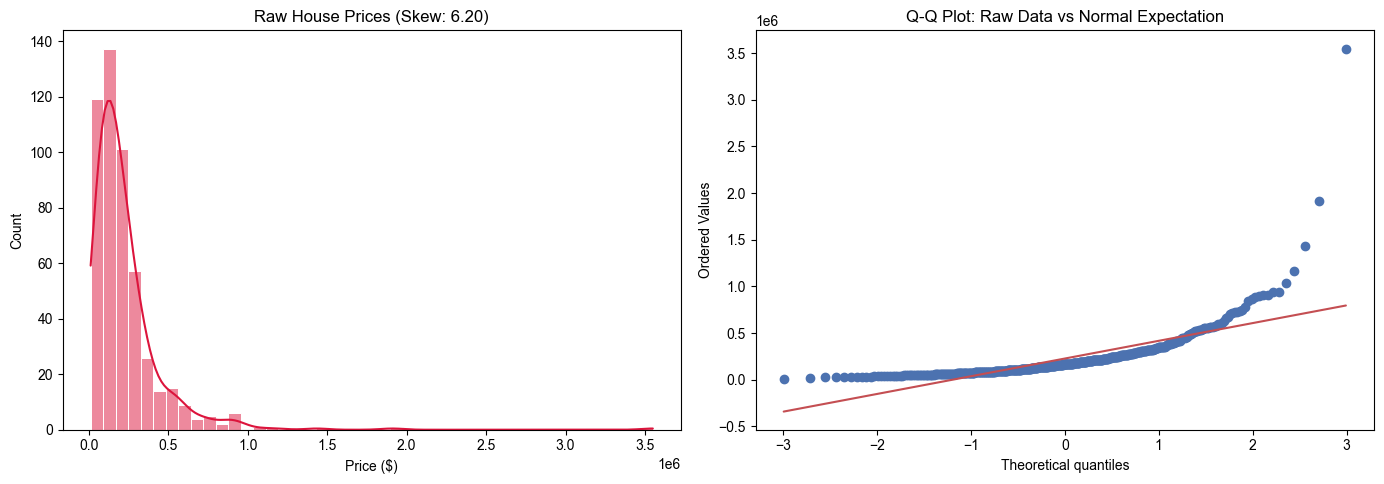

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="whitegrid")

# Left Plot: Skewed Histogram with a kernel density estimate curve
sns.histplot(df['raw_price'], kde=True, color="crimson", ax=axes[0])
axes[0].set_title(f"Raw House Prices (Skew: {raw_skew:.2f})")
axes[0].set_xlabel("Price ($)")

# Right Plot: Q-Q Plot comparing our data distribution to a theoretical perfect normal distribution
stats.probplot(df['raw_price'], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Raw Data vs Normal Expectation")

plt.tight_layout()
plt.show()

# Pipeline Stage 4: Mathematical Log Transformation

### 🔍 What It Does
This cell addresses the distributional imbalance by applying a logarithmic compression function (`np.log1p`) to the raw prices. It then immediately re-audits the column to compute the new post-transformation skewness metrics.

### 🎯 Why We Did It
A logarithmic transformation acts like a mathematical lens: it compresses massive outlier scales (like a $5,000,000 mansion) exponentially more than it scales standard values (like a $150,000 house). This narrows the extreme variance gap, pulling the entire data spread back into a tight, stabilized metric scale and forcing the new skewness score to drop close to a perfect `0`.

In [4]:
# Apply the natural log transformation to pull the high-end outlier values closer to the center
df['transformed_price'] = np.log1p(df['raw_price'])
transformed_skew = df['transformed_price'].skew()

print("=== POST-TRANSFORMATION MATRIX ===")
print(f"New Transformed Skewness Score: {transformed_skew:.4f}")
print("System Status: Data successfully normalized for AI ingestion.")

=== POST-TRANSFORMATION MATRIX ===
New Transformed Skewness Score: 0.1802
System Status: Data successfully normalized for AI ingestion.


# Pipeline Stage 5: Verifying the Normalized Solution

### 🔍 What It Does
This cell plots the final post-transformation diagnostic visuals to verify the success of the pipeline. It renders a clean, balanced histogram alongside a final Q-Q plot where the blue data points now lock perfectly onto the straight normal reference line.

### 🎯 Why We Did It
This final visual sweep confirms that our mathematical adjustments successfully eliminated structural bias from the dataset. The crashing wave has been converted into a perfect symmetric bell curve (Normal Distribution), and the Q-Q plot confirms the data points snap onto the normal line like a zipper. The feature is now fully optimized and safe for AI model ingestion.

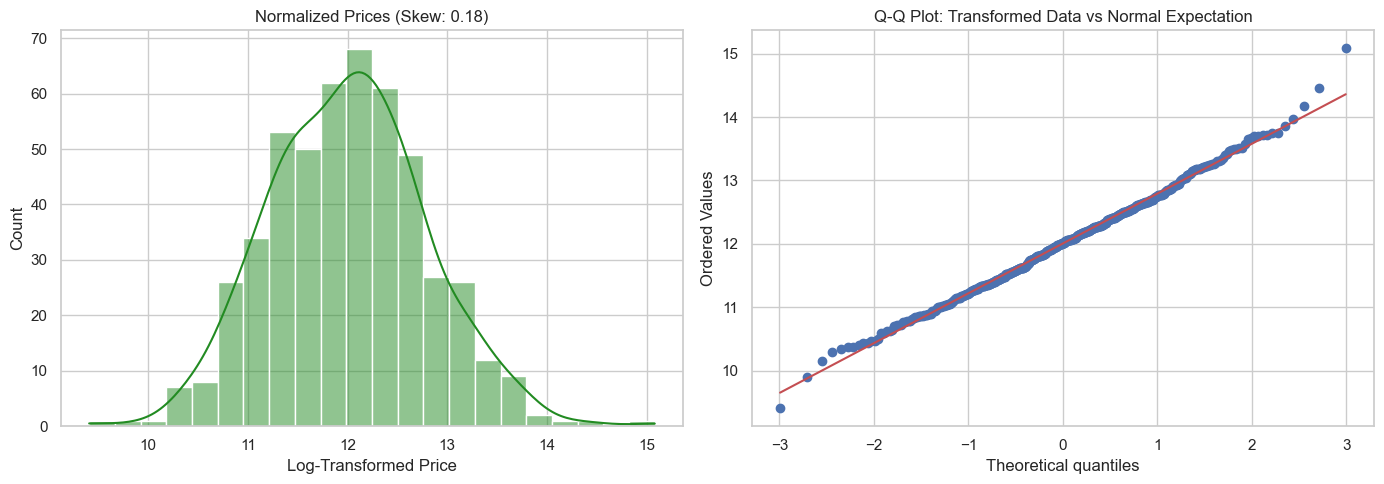

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: The newly shaped symmetric bell curve histogram
color_choice = "emerald" if transformed_skew < 0.5 else "forestgreen"
sns.histplot(df['transformed_price'], kde=True, color="forestgreen", ax=axes[0])
axes[0].set_title(f"Normalized Prices (Skew: {transformed_skew:.2f})")
axes[0].set_xlabel("Log-Transformed Price")

# Right Plot: Transformed Q-Q Plot showing data points now locking perfectly onto the red normal line
stats.probplot(df['transformed_price'], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Transformed Data vs Normal Expectation")

plt.tight_layout()
plt.show()